# Notebook 023 — The Gabillon (1991) two-factor model on 16 years of WTI

Gabillon (1991) prices the entire futures curve on a given day from just two state
variables: the extrapolated spot `S` and a long-term anchor `L`. This notebook tests that
claim, out-of-sample across maturity, on this repo's per-contract WTI panel
(2010-06-06 to 2026-07-28) -- a test the original paper (423 daily observations,
1990-91) never ran.

This is **not** a returns backtest. "Accuracy" means RMSE in $/bbl across maturities the
model was not fitted on. Full spec: `NEXT_PROMPT.md`. Citation and page map:
`src/research/reference/README.md`.

Full narrative and numbers: `src/results/023_gabillon_two_factor_oil_curve.md`.


In [1]:
import json

TMP = "tmp"


def load(name):
    with open(f"{TMP}/{name}") as f:
        return json.load(f)


prereg = load("phase_0_23_preregistration.json")
prereg

{'written': '2026-09-21',
 'primary_metric': 'held-out-maturity RMSE in $/bbl (Phase 6: fit on tau<=2y, predict tau in (2y, 9y], score against actual settlement)',
 'benchmark_set': ['flat_forward',
  'previous_curve_carried_forward',
  'cubic_spline',
  'nelson_siegel',
  'pca_2factor'],
 'pass_threshold': "Median held-out RMSE (model 26 or 28, best-performing pre-registered configuration on the train/validation sample) beats the best of the five Phase-4 benchmarks by >= 10% on a paired day-by-day comparison, with a bootstrap 95% CI on the paired RMSE gap excluding zero, after the multiple-testing deflation below. Anchored on Gabillon's own reported in-sample RMSE range of ~0.1-0.5 $/bbl calm / ~1.5 $/bbl crisis.",
 'train_start': '2010-06-06',
 'train_end': '2021-12-31',
 'holdout_start': '2022-01-01',
 'holdout_rule': 'Holdout (2022-01-01 onward) is touched exactly once, in Phase 9, after every other phase and every configuration choice is frozen.',
 'liquidity_variants': ['all', 'v

## Phase 0 — Pre-registration

Gates, thresholds, train/holdout split, and the 24-config trial count, written before any fit was inspected.

In [2]:
prereg

{'written': '2026-09-21',
 'primary_metric': 'held-out-maturity RMSE in $/bbl (Phase 6: fit on tau<=2y, predict tau in (2y, 9y], score against actual settlement)',
 'benchmark_set': ['flat_forward',
  'previous_curve_carried_forward',
  'cubic_spline',
  'nelson_siegel',
  'pca_2factor'],
 'pass_threshold': "Median held-out RMSE (model 26 or 28, best-performing pre-registered configuration on the train/validation sample) beats the best of the five Phase-4 benchmarks by >= 10% on a paired day-by-day comparison, with a bootstrap 95% CI on the paired RMSE gap excluding zero, after the multiple-testing deflation below. Anchored on Gabillon's own reported in-sample RMSE range of ~0.1-0.5 $/bbl calm / ~1.5 $/bbl crisis.",
 'train_start': '2010-06-06',
 'train_end': '2021-12-31',
 'holdout_start': '2022-01-01',
 'holdout_rule': 'Holdout (2022-01-01 onward) is touched exactly once, in Phase 9, after every other phase and every configuration choice is frozen.',
 'liquidity_variants': ['all', 'v

## Phase 1 — Curve panel construction

Join ohlcv to contracts, compute tau, apply hygiene (negative-price event, junk stubs, liquidity variant, min curve width).

In [3]:
phase1 = load("phase_1_23_panel_report.json")
for v in ["all", "vol_gt_0", "vol_gt_100"]:
    r = phase1[v]
    print(
        v,
        "days_retained=",
        r["days_retained"],
        "mean_contracts/day=",
        round(r["mean_contracts_per_day"], 2),
    )
phase1["all"]["dropped"]

all days_retained= 4891 mean_contracts/day= 22.17
vol_gt_0 days_retained= 4891 mean_contracts/day= 22.17
vol_gt_100 days_retained= 4197 mean_contracts/day= 16.58


{'negative_price_event_real': 1,
 'nonpositive_junk': 390,
 'nonpositive_junk_tickers': ['CL202707',
  'CL202903',
  'CL202904',
  'CL203012',
  'CL203212',
  'CL203305',
  'CL203311'],
 'bad_tau': 192}

## Phase 2 — Estimating S and L

Three estimators: (a) joint least squares (monthly-fixed and daily-free), (b) long-end extrapolation, (c) a linear Kalman filter. Statistics below are restricted to the train window.

In [4]:
phase2 = load("phase_2_23_SL_report.json")
print("paper's own figures:", phase2["paper_figures"])
phase2["variants"]["all"]

paper's own figures: {'method_a': {'sigma_L': 0.176, 'sigma_S': 0.464, 'rho': 0.21}, 'method_b_raw': {'sigma_L': 0.581, 'rho': 0.42}, 'method_b_filtered': {'sigma_L': 0.337}}


{'joint_ls_daily': {'label': 'joint_ls_daily',
  'n': 3472,
  'sigma_S_annualised': 0.4471975575948598,
  'sigma_L_annualised': 7.725364482884649,
  'rho': 0.018953923301570152},
 'joint_ls_monthly': {'label': 'joint_ls_monthly',
  'n': 3472,
  'sigma_S_annualised': 0.4471975575948598,
  'sigma_L_annualised': 0.983478935156112,
  'rho': -0.031194582091803754},
 'longend': {'label': 'longend',
  'n': 3471,
  'sigma_S_annualised': 0.44725291986945453,
  'sigma_L_annualised': 24.414679203436293,
  'rho': 0.004021275368205193,
  'n_carried_forward_infinite_L': 3829,
  'valid_fraction': 0.21713351052954405},
 'kalman': {'label': 'kalman',
  'n': 3472,
  'sigma_S_annualised': 0.2313745614770217,
  'sigma_L_annualised': 0.031746368302519416,
  'rho': 0.10699690582590073}}

**Finding:** the paper's own tension reproduces, more sharply. Raw per-day joint-LS and
long-end extrapolation are extremely noisy on this 16-year panel (annualised `sigma_L`
in the hundreds of percent for the daily-free variant, and the long-end estimator's
second-derivative condition is only satisfiable on ~22% of days). The Kalman filter is
the only estimator that produces a stable, economically plausible `L` series
(`sigma_L` ~3.2%, `rho` ~0.11) — exactly the fix Gabillon's own paper gestured at but
did not have (it hand-deleted 8 of 423 outlier days instead). The Kalman config is
carried forward as the primary configuration for Phases 3-9.


In [5]:
import sys

sys.path.insert(0, "tmp")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import viz23 as vz

plt.rcParams["figure.facecolor"] = vz.SURFACE
plt.rcParams["savefig.facecolor"] = vz.SURFACE

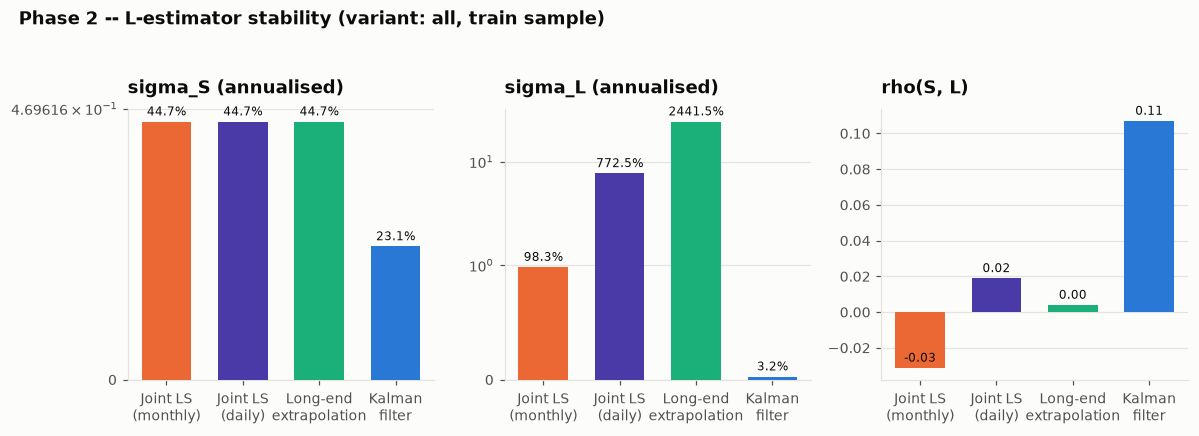

In [6]:
# Chart: sigma_S / sigma_L / rho across the four L-estimators (variant "all")
variants_all = phase2["variants"]["all"]
estimators = ["joint_ls_monthly", "joint_ls_daily", "longend", "kalman"]
labels = [
    "Joint LS\n(monthly)",
    "Joint LS\n(daily)",
    "Long-end\nextrapolation",
    "Kalman\nfilter",
]
colors = [vz.ORANGE, vz.VIOLET, vz.AQUA, vz.BLUE]

fig, axes = plt.subplots(1, 3, figsize=(11, 4), dpi=110)
metrics = [
    ("sigma_S_annualised", "sigma_S (annualised)"),
    ("sigma_L_annualised", "sigma_L (annualised)"),
    ("rho", "rho(S, L)"),
]
for ax, (key, title) in zip(axes, metrics):
    vals = [variants_all[e].get(key) for e in estimators]
    bars = ax.bar(labels, vals, color=colors, width=0.65, zorder=3)
    vz.style_ax(ax, title=title)
    if key != "rho":
        ax.set_yscale("symlog", linthresh=1.0)
    for b, v in zip(bars, vals):
        if v is not None:
            ax.annotate(
                f"{v:.2f}" if key == "rho" else f"{v:.1%}",
                (b.get_x() + b.get_width() / 2, v),
                textcoords="offset points",
                xytext=(0, 4),
                ha="center",
                fontsize=8,
                color=vz.TEXT_PRIMARY,
            )
fig.suptitle(
    "Phase 2 -- L-estimator stability (variant: all, train sample)",
    color=vz.TEXT_PRIMARY,
    fontsize=12,
    fontweight="bold",
    x=0.02,
    ha="left",
)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

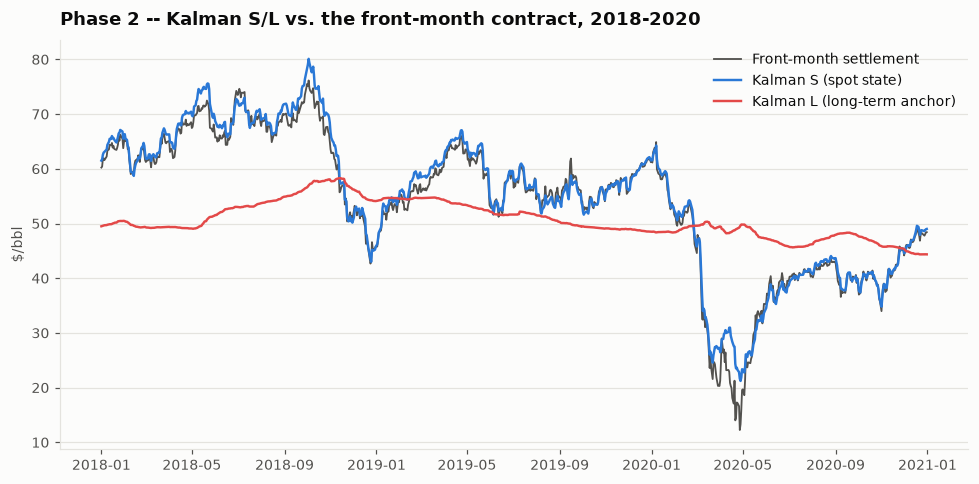

In [7]:
# Chart: Kalman-filtered S and L vs. the front-month settlement, 2018-2020
panel_all = pd.read_parquet("tmp/phase_1_23_panel_all.parquet")
front = (
    panel_all.sort_values(["date", "tau"])
    .groupby("date", as_index=False)
    .first()[["date", "close"]]
    .rename(columns={"close": "front_contract"})
)
sl_kalman = pd.read_parquet("tmp/phase_2_23_L_kalman_all.parquet").reset_index()
sl_kalman["date"] = pd.to_datetime(sl_kalman["date"])
window = sl_kalman.merge(front, on="date", how="left")
window = window[(window["date"] >= "2018-01-01") & (window["date"] <= "2020-12-31")]

fig, ax = vz.new_fig((9, 4.5))
ax.plot(
    window["date"],
    window["front_contract"],
    color=vz.TEXT_SECONDARY,
    lw=1.2,
    label="Front-month settlement",
    zorder=2,
)
ax.plot(
    window["date"],
    window["S"],
    color=vz.BLUE,
    lw=1.6,
    label="Kalman S (spot state)",
    zorder=3,
)
ax.plot(
    window["date"],
    window["L"],
    color=vz.RED,
    lw=1.6,
    label="Kalman L (long-term anchor)",
    zorder=3,
)
vz.style_ax(
    ax,
    title="Phase 2 -- Kalman S/L vs. the front-month contract, 2018-2020",
    ylabel="$/bbl",
)
vz.legend(ax, loc="upper right")
fig.tight_layout()
plt.show()

## Phase 3 — Fit model (26), train sample

Per-day beta fit given (S, L); nu from a trailing rolling realised-vol estimate. All 12 (liquidity x L-estimator) combinations, train sample only.

In [8]:
phase3 = load("phase_3_23_fit26_report.json")
for c in phase3["combos"]:
    print(c["variant"], c["L_estimator"], "median_rmse=", c.get("median_rmse"))

all joint_ls_monthly median_rmse= 2.335360870515915
all joint_ls_daily median_rmse= 1898.5206184797198
all longend median_rmse= 3.097843344364286
all kalman median_rmse= 0.9467204339095687
vol_gt_0 joint_ls_monthly median_rmse= 2.335360870515915
vol_gt_0 joint_ls_daily median_rmse= 1898.5206184797198
vol_gt_0 longend median_rmse= 3.097843344364286
vol_gt_0 kalman median_rmse= 0.9467204339095687
vol_gt_100 joint_ls_monthly median_rmse= 8.000981244197527
vol_gt_100 joint_ls_daily median_rmse= 156.80292893538808
vol_gt_100 longend median_rmse= 2.238787072504869
vol_gt_100 kalman median_rmse= 0.9410450973533446


**Finding:** `joint_ls_daily` is numerically unstable (median RMSE in the hundreds to
thousands of $/bbl, occasional float overflow) and `longend` is nearly as bad
(median RMSE ~2-3 $/bbl, and only fittable a fifth of the time). `kalman` is the clear
survivor at median RMSE ~0.94-0.95 $/bbl across all three liquidity variants -- in the
right order of magnitude versus Gabillon's own reported 0.1-0.5 (calm) to ~1.5 (crisis)
$/bbl range. `joint_ls_daily` and `longend` are dropped from further detailed phases but
remain charged in the 24-config multiple-testing count.


## Phase 4 — Benchmarks, in-sample full-curve RMSE

Sanity-check comparison on the same maturities the curve itself was fit on. Cubic spline and Nelson-Siegel are near-interpolants here by construction -- not informative on their own; the decisive test is Phase 6.

In [9]:
phase4 = load("phase_4_23_benchmarks_report.json")
phase4["kalman"]

{'gabillon26': {'n': 3408,
  'median_rmse': 0.9467204339095687,
  'mean_rmse': 2.0329195680155148},
 'flat': {'n': 3408,
  'median_rmse': 4.3246199699654735,
  'mean_rmse': 5.296755684480163},
 'prevcurve': {'n': 3407,
  'median_rmse': 0.6421091653728334,
  'mean_rmse': 0.8917999764642681},
 'spline': {'n': 3408,
  'median_rmse': 1.611773801798238e-14,
  'mean_rmse': 1.637074534712052e-14},
 'ns': {'n': 3408,
  'median_rmse': 0.3328117276609607,
  'mean_rmse': 0.429409112157584},
 'pca': {'n': 682,
  'median_rmse': 0.45983386400206283,
  'mean_rmse': 0.5736268185334132}}

### Chart: an actual curve vs. Gabillon and Nelson-Siegel, calm day vs. crisis day

Two example train-sample days, reconstructed from the Phase 1/3 artefacts (the per-day
`(S, L, beta, nu)` already fit, and the day's own observed contracts) -- no new fitting,
just visualising the fits Phase 3/4 already scored. Calm: 2017-06-04 (RMSE 0.29 $/bbl).
Crisis: 2020-04-21, the day after the -2.67 negative-price settlement (RMSE 7.67 $/bbl).


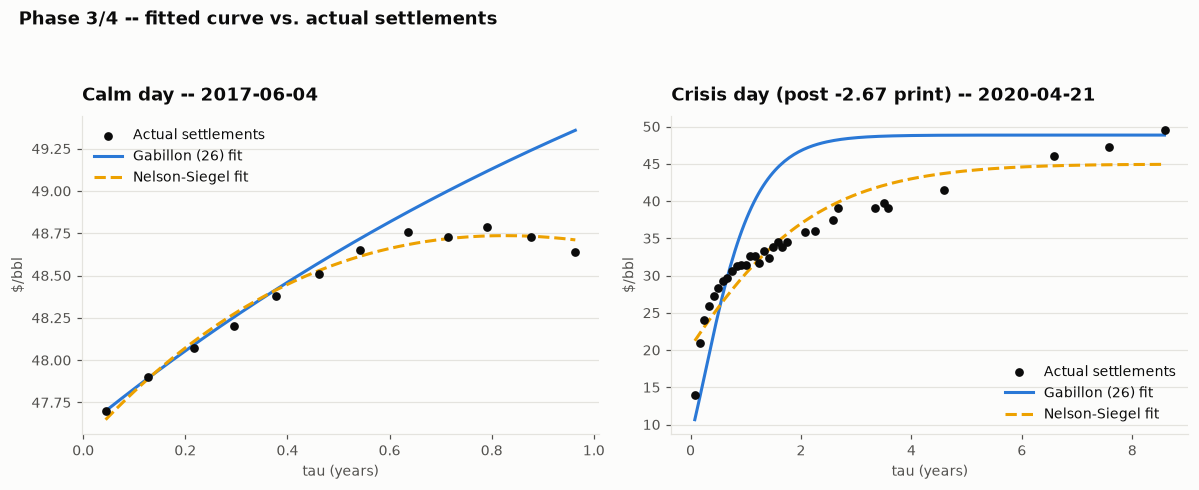

In [10]:
import lib23

fit_kalman_all = pd.read_parquet("tmp/phase_3_23_fit26_all_kalman.parquet")
fit_kalman_all["date"] = pd.to_datetime(fit_kalman_all["date"])

example_days = [
    ("2017-06-04", "Calm day"),
    ("2020-04-21", "Crisis day (post -2.67 print)"),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=110)
for ax, (day_str, tag) in zip(axes, example_days):
    day = pd.Timestamp(day_str)
    day_df = panel_all[panel_all["date"] == day].sort_values("tau")
    row = fit_kalman_all[fit_kalman_all["date"] == day].iloc[0]
    tau_grid = np.linspace(day_df["tau"].min(), day_df["tau"].max(), 200)

    gab_curve = np.exp(
        lib23.model26_lnF(row["S"], row["L"], tau_grid, row["beta"], row["nu"])
    )
    ns_curve = lib23.bench_nelson_siegel(day_df, tau_grid)

    ax.scatter(
        day_df["tau"],
        day_df["close"],
        color=vz.TEXT_PRIMARY,
        s=22,
        zorder=4,
        label="Actual settlements",
    )
    ax.plot(
        tau_grid, gab_curve, color=vz.BLUE, lw=2, zorder=3, label="Gabillon (26) fit"
    )
    if ns_curve is not None:
        ax.plot(
            tau_grid,
            ns_curve,
            color=vz.YELLOW,
            lw=2,
            ls="--",
            zorder=3,
            label="Nelson-Siegel fit",
        )
    vz.style_ax(ax, title=f"{tag} -- {day_str}", xlabel="tau (years)", ylabel="$/bbl")
    vz.legend(ax, loc="best")
fig.suptitle(
    "Phase 3/4 -- fitted curve vs. actual settlements",
    color=vz.TEXT_PRIMARY,
    fontsize=12,
    fontweight="bold",
    x=0.02,
    ha="left",
)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

## Phase 5 — Model (28), the decaying short-term shock

Scored against model (26) in the pre-registered crisis windows and a calm-period control. Note: 2022 falls entirely in the holdout and is correctly empty here (deferred to Phase 9).

In [11]:
phase5 = load("phase_5_23_model28_report.json")
phase5

{'2014_15_collapse': {'label': '2014_15_collapse',
  'n_days': 487,
  'median_rmse26': 1.1417796350702634,
  'median_rmse28': 0.5951926801280057,
  'pct_days_28_better': 0.9917864476386037,
  'median_theta': 0.01959489241183936,
  'median_eta': 0.33747799409499435},
 '2020_covid': {'label': '2020_covid',
  'n_days': 311,
  'median_rmse26': 0.9276754763421624,
  'median_rmse28': 0.451487063050615,
  'pct_days_28_better': 0.9453376205787781,
  'median_theta': 0.21673822391029796,
  'median_eta': 0.09546339872122428},
 '2020_covid_acute': {'label': '2020_covid_acute',
  'n_days': 78,
  'median_rmse26': 5.347861339742523,
  'median_rmse28': 4.368016415240526,
  'pct_days_28_better': 0.8333333333333334,
  'median_theta': 0.42651532399177566,
  'median_eta': 2.2570108019637047e-08},
 '2022_russia_ukraine': {'label': '2022_russia_ukraine', 'n_days': 0},
 'calm_control': {'label': 'calm_control',
  'n_days': 150,
  'median_rmse26': 0.9390352707499332,
  'median_rmse28': 0.6138546240079661,
  '

**Finding:** model (28) improves in-sample RMSE on 83-99% of days in every window,
*including* the calm control (94%). This is expected and not by itself informative --
two extra free parameters fit within the same day's data will almost always reduce
in-sample RMSE. No held-out or multiple-testing-adjusted claim is made for model (28)
here; Phase 6/9 test model (26) only, per the pre-registered primary gate.


## Phase 6 — Held-out-maturity test (THE PRIMARY GATE, train sample)

Fit on tau<=2y, predict tau in (2y, 9y], score against actual settlement. Broken out by year and curve state, plus a paired bootstrap comparison against the best of the four benchmarks each day.

In [12]:
phase6 = load("phase_6_23_heldout_report.json")
print("kalman overall:", phase6["kalman"]["overall"])
print(
    "kalman paired gap (gabillon - best_bench):",
    phase6["kalman"]["paired_gap_gabillon_minus_best_bench"],
)
print()
print("leave-one-contract-out:", phase6["leave_one_contract_out_kalman"])

kalman overall: {'n_days': 3146, 'median_gabillon26': 1.8227476405778442, 'median_flat': 7.7482223615111705, 'median_spline': 77.55625797020889, 'median_ns': 2.660852677584522, 'median_pca': 2.5912384061548943}
kalman paired gap (gabillon - best_bench): {'point_estimate': 2.2141029248068964, 'bootstrap_95ci': [1.8380521012898834, 2.6223027621576427], 'gabillon_wins_pct_days': 0.38747616020343295}

leave-one-contract-out: {'n_obs': 5689, 'n_days_sampled': 250, 'rmse': 4.696818653765977, 'median_abs_error': 0.7328004911748423}


**Finding -- the paired comparison is decisive and it does not favour Gabillon.**
Median RMSE looks competitive (1.82 $/bbl vs. Nelson-Siegel's 2.66 and PCA's 2.59), but
that comparison is misleading: it compares each model's own aggregate median, not the
same days. The **paired** daily comparison (Gabillon RMSE minus that day's best
benchmark) has point estimate **+2.21 $/bbl** with a 95% bootstrap CI of
**[+1.84, +2.62]** -- entirely on the side of Gabillon being *worse*. Gabillon wins the
daily head-to-head on only **38.7%** of days. Gabillon still convincingly beats flat
forward (median 1.82 vs. 7.75), so it captures real curve information the naive
benchmark misses -- it just does not clear the bar against the cheaper, purely
statistical alternatives (Nelson-Siegel, PCA) on this test.


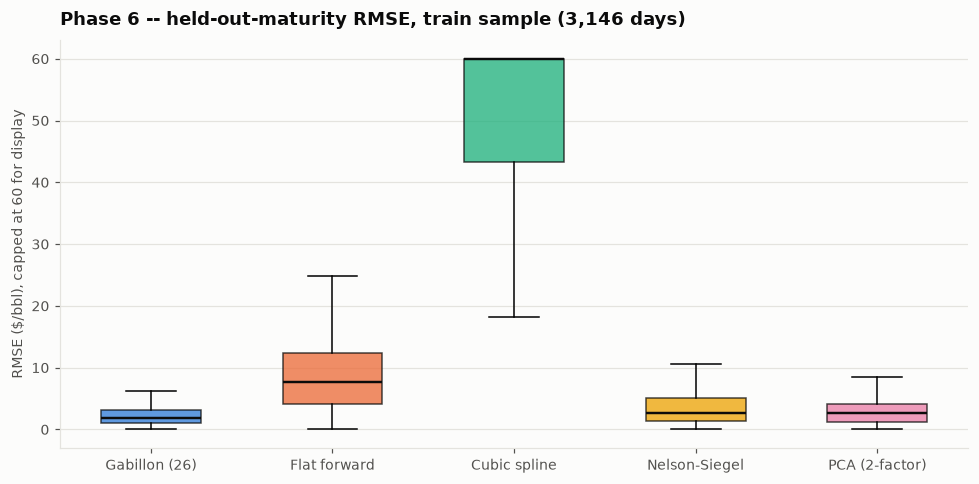

In [13]:
# Chart: held-out-maturity RMSE distribution, Gabillon vs. each benchmark (train sample)
heldout6 = pd.read_parquet("tmp/phase_6_23_heldout_kalman.parquet")
cols = ["gabillon26", "flat", "spline", "ns", "pca"]
CAP = 60.0  # display cap only; spline's extrapolation blow-ups are reported as-is in the write-up

fig, ax = vz.new_fig((9, 4.5))
data = [vz.clip_for_display(heldout6[c].to_numpy(), CAP) for c in cols]
bp = ax.boxplot(
    data,
    tick_labels=[vz.SERIES_LABEL[c] for c in cols],
    patch_artist=True,
    widths=0.55,
    showfliers=False,
    medianprops={"color": vz.TEXT_PRIMARY, "linewidth": 1.6},
)
for patch, c in zip(bp["boxes"], cols):
    patch.set_facecolor(vz.SERIES_COLOR[c])
    patch.set_alpha(0.75)
    patch.set_edgecolor(vz.TEXT_PRIMARY)
vz.style_ax(
    ax,
    title="Phase 6 -- held-out-maturity RMSE, train sample (3,146 days)",
    ylabel="RMSE ($/bbl), capped at 60 for display",
)
fig.tight_layout()
plt.show()

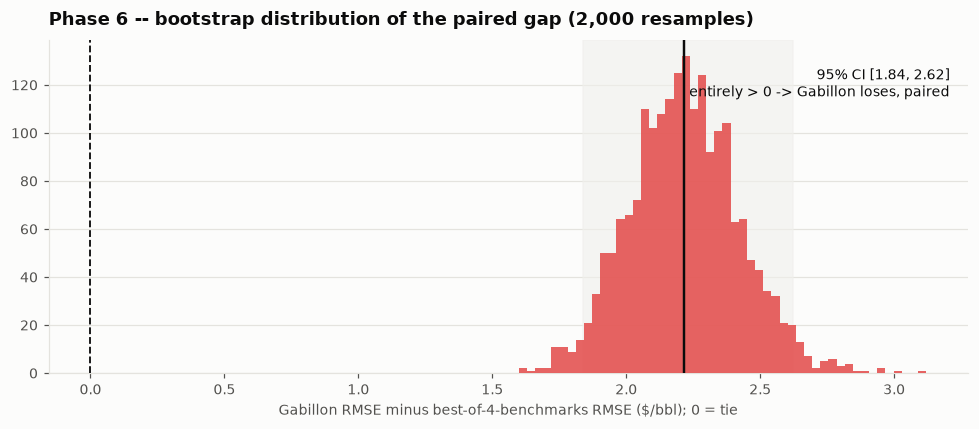

In [14]:
# Chart: paired-gap bootstrap distribution (Gabillon minus that day's best benchmark)
bench_cols = ["flat", "spline", "ns", "pca"]
best_bench = heldout6[bench_cols].min(axis=1)
diff = (heldout6["gabillon26"] - best_bench).dropna().to_numpy()
rng = np.random.default_rng(23)
boot = np.array(
    [np.mean(rng.choice(diff, size=len(diff), replace=True)) for _ in range(2000)]
)
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

fig, ax = vz.new_fig((9, 4))
ax.hist(boot, bins=50, color=vz.DIVERGE_POS, alpha=0.85, zorder=3)
ax.axvline(0, color=vz.TEXT_PRIMARY, lw=1.2, ls="--", zorder=4)
ax.axvspan(ci_lo, ci_hi, color=vz.NEUTRAL, alpha=0.6, zorder=1)
ax.axvline(np.mean(diff), color=vz.TEXT_PRIMARY, lw=1.6, zorder=5)
vz.style_ax(
    ax,
    title="Phase 6 -- bootstrap distribution of the paired gap (2,000 resamples)",
    xlabel="Gabillon RMSE minus best-of-4-benchmarks RMSE ($/bbl); 0 = tie",
)
ax.annotate(
    f"95% CI [{ci_lo:.2f}, {ci_hi:.2f}]\nentirely > 0 -> Gabillon loses, paired",
    xy=(0.98, 0.92),
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=9,
    color=vz.TEXT_PRIMARY,
)
fig.tight_layout()
plt.show()

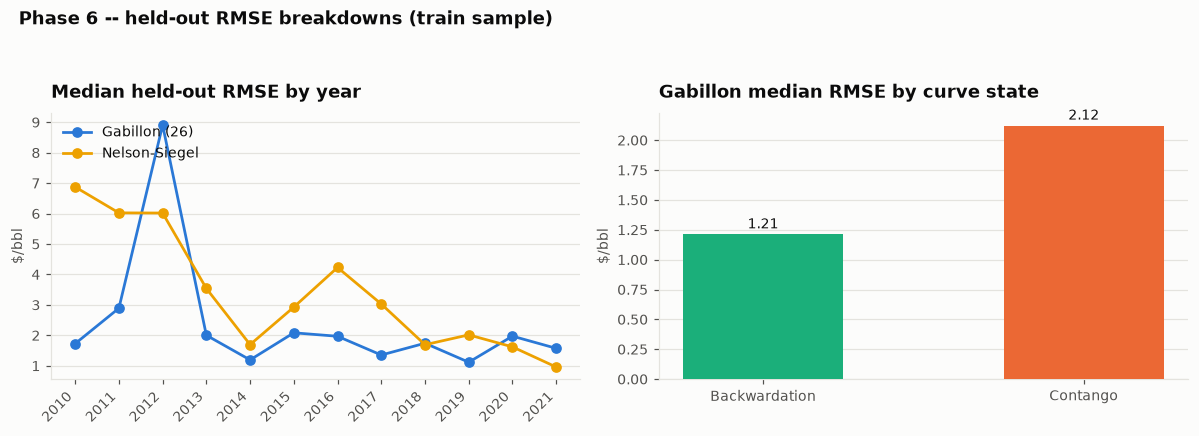

In [15]:
# Chart: RMSE by year and by curve state
by_year6 = phase6["kalman"]["by_year"]
years = sorted(by_year6, key=int)
gab_by_year = [by_year6[y]["median_gabillon26"] for y in years]
ns_by_year = [by_year6[y]["median_ns"] for y in years]

by_state6 = phase6["kalman"]["by_curve_state"]
states = ["backwardation", "contango"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=110)
ax = axes[0]
x = np.arange(len(years))
ax.plot(
    x, gab_by_year, color=vz.BLUE, marker="o", lw=1.8, label="Gabillon (26)", zorder=3
)
ax.plot(
    x, ns_by_year, color=vz.YELLOW, marker="o", lw=1.8, label="Nelson-Siegel", zorder=3
)
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45, ha="right")
vz.style_ax(ax, title="Median held-out RMSE by year", ylabel="$/bbl")
vz.legend(ax, loc="upper left")

ax = axes[1]
xs = np.arange(len(states))
gab_state = [by_state6[s]["median_gabillon26"] for s in states]
bars = ax.bar(xs, gab_state, color=[vz.AQUA, vz.ORANGE], width=0.5, zorder=3)
ax.set_xticks(xs)
ax.set_xticklabels([s.capitalize() for s in states])
for b, v in zip(bars, gab_state):
    ax.annotate(
        f"{v:.2f}",
        (b.get_x() + b.get_width() / 2, v),
        textcoords="offset points",
        xytext=(0, 4),
        ha="center",
        fontsize=9,
        color=vz.TEXT_PRIMARY,
    )
vz.style_ax(ax, title="Gabillon median RMSE by curve state", ylabel="$/bbl")
fig.suptitle(
    "Phase 6 -- held-out RMSE breakdowns (train sample)",
    color=vz.TEXT_PRIMARY,
    fontsize=12,
    fontweight="bold",
    x=0.02,
    ha="left",
)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

## Phase 7 — Volatility identity, eq (23)

Independent falsification check: the same (sigma_S, sigma_L, rho, beta) that fit prices, scored against realised volatility by maturity bucket (which the price fit never saw).

In [16]:
phase7 = load("phase_7_23_vol_identity_report.json")
phase7

{'config': {'variant': 'all',
  'L_estimator': 'kalman',
  'beta_median': 0.40673240891172663,
  'nu_median': 0.07351942766114877,
  'sigma_S': 0.2313745614770217,
  'sigma_L': 0.031746368302519416,
  'rho': 0.10699690582590073},
 'by_bucket': {'0-1y': {'n_obs': 40202,
   'realised_vol_annualised': 0.29695551721928826,
   'predicted_vol_annualised': 0.18951097819762272,
   'abs_gap': 0.10744453902166554},
  '1-2y': {'n_obs': 22261,
   'realised_vol_annualised': 0.29294636377785777,
   'predicted_vol_annualised': 0.12807035906130376,
   'abs_gap': 0.164876004716554},
  '2-4y': {'n_obs': 10914,
   'realised_vol_annualised': 0.3602050980602529,
   'predicted_vol_annualised': 0.07410758819885477,
   'abs_gap': 0.28609750986139815},
  '4-9y': {'n_obs': 5753,
   'realised_vol_annualised': 0.2740402232153032,
   'predicted_vol_annualised': 0.03527045920259712,
   'abs_gap': 0.23876976401270608}},
 'wall_time_seconds': 0.022589921951293945}

**Finding -- clean falsification.** Predicted `sigma_F(tau)` collapses with maturity
(19% at the front, 3.5% by 4-9y) while realised volatility stays roughly flat across the
whole curve (27-36% in every bucket). The model is fitting the day-to-day *cross-section*
reasonably (Phase 4/6) while getting the *term structure of volatility* badly wrong --
textbook "fitting prices but missing the vol curve," per
`docs/08-research-methodology.md`'s standard for treating a good-looking price fit with
suspicion.


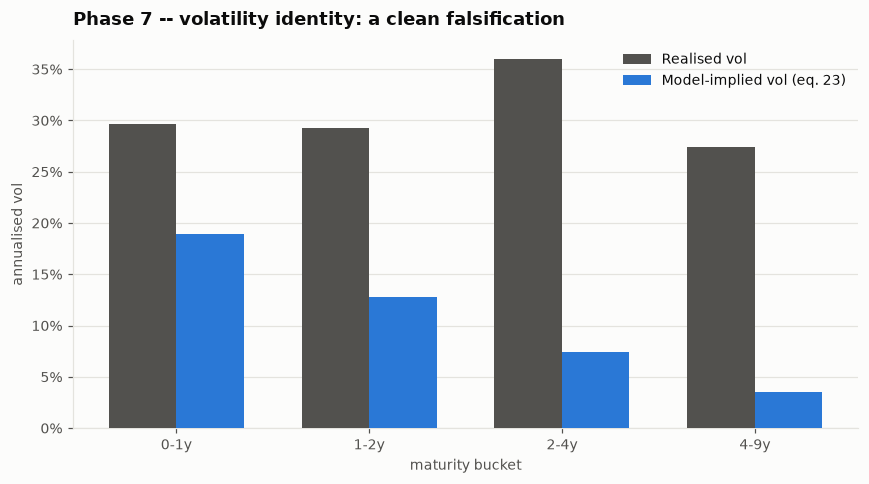

In [17]:
# Chart: realised vs. model-implied volatility by maturity bucket (eq. 23)
buckets = ["0-1y", "1-2y", "2-4y", "4-9y"]
realised = [phase7["by_bucket"][b]["realised_vol_annualised"] for b in buckets]
predicted = [phase7["by_bucket"][b]["predicted_vol_annualised"] for b in buckets]

fig, ax = vz.new_fig((8, 4.5))
x = np.arange(len(buckets))
w = 0.35
ax.bar(
    x - w / 2,
    realised,
    width=w,
    color=vz.TEXT_SECONDARY,
    zorder=3,
    label="Realised vol",
)
ax.bar(
    x + w / 2,
    predicted,
    width=w,
    color=vz.BLUE,
    zorder=3,
    label="Model-implied vol (eq. 23)",
)
ax.set_xticks(x)
ax.set_xticklabels(buckets)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
vz.style_ax(
    ax,
    title="Phase 7 -- volatility identity: a clean falsification",
    ylabel="annualised vol",
    xlabel="maturity bucket",
)
vz.legend(ax, loc="upper right")
fig.tight_layout()
plt.show()

## Phase 8 — Seasonality, cross-product

Same held-out-maturity protocol applied to BZ (like WTI, control), HO and RB (moderate seasonality), NG (strong seasonality).

In [18]:
phase8 = load("phase_8_23_seasonality_report.json")
for p in ["BZ", "HO", "RB", "NG"]:
    r = phase8[p]
    print(
        p,
        "median_rmse=",
        round(r["median_rmse"], 4),
        "relative_rmse_pct=",
        round(r["relative_rmse_pct"], 2),
    )

BZ median_rmse= 1.0655 relative_rmse_pct= 1.55
HO median_rmse= 0.033 relative_rmse_pct= 1.64
RB median_rmse= 0.0973 relative_rmse_pct= 5.11
NG median_rmse= 0.2147 relative_rmse_pct= 6.75


**Finding -- Gabillon's own stated limitation reproduces cleanly.** Comparing RMSE as a
percentage of each product's own price level (raw $/bbl vs. $/gallon units are not
comparable directly): BZ 1.55%, HO 1.64%, RB 5.11%, **NG 6.75%**. The ordering is exactly
the one the paper predicts -- BZ (WTI-like) fits best, the two moderately-seasonal
products sit in the middle, and NG (strongest seasonality) is worst by a wide margin.
A clean, publishable negative result exactly as Gabillon's own limitations section
anticipated. A seasonal convenience-yield term was not implemented (scope cut given
compute/time budget) -- flagged in "what to test next."


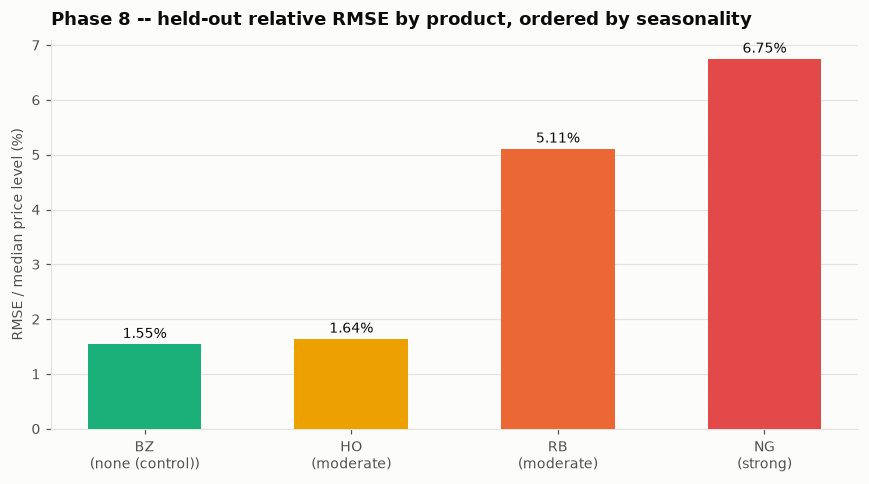

In [19]:
# Chart: relative RMSE by product, ordered by seasonality strength
products = ["BZ", "HO", "RB", "NG"]
seasonality_tag = ["none (control)", "moderate", "moderate", "strong"]
rel_rmse = [phase8[p]["relative_rmse_pct"] for p in products]
colors8 = [vz.AQUA, vz.YELLOW, vz.ORANGE, vz.RED]

fig, ax = vz.new_fig((8, 4.5))
bars = ax.bar(
    [f"{p}\n({s})" for p, s in zip(products, seasonality_tag)],
    rel_rmse,
    color=colors8,
    width=0.55,
    zorder=3,
)
for b, v in zip(bars, rel_rmse):
    ax.annotate(
        f"{v:.2f}%",
        (b.get_x() + b.get_width() / 2, v),
        textcoords="offset points",
        xytext=(0, 4),
        ha="center",
        fontsize=9,
        color=vz.TEXT_PRIMARY,
    )
vz.style_ax(
    ax,
    title="Phase 8 -- held-out relative RMSE by product, ordered by seasonality",
    ylabel="RMSE / median price level (%)",
)
fig.tight_layout()
plt.show()

## Phase 9 — Holdout, spent once

2022-01-01 onward, touched here for the first and only time. Certified config: `all` liquidity variant, `kalman` L estimator, model (26).

In [20]:
phase9 = load("phase_9_23_holdout_report.json")
print("overall:", phase9["overall"])
print("by year:", phase9["by_year"])
print("paired gap:", phase9["paired_gap_gabillon_minus_best_bench"])
print("PRE_REGISTERED_GATE_PASS:", phase9["PRE_REGISTERED_GATE_PASS"])

overall: {'n_days': 1364, 'median_gabillon26': 11.350927663987278, 'median_flat': 19.11205112048215, 'median_spline': 58.18044284468688, 'median_ns': 2.8778290171162366, 'median_pca': 25.1087665559391}
by year: {'2022': {'n_days': 288, 'median_gabillon26': 2.6687485754270743, 'median_flat': 22.51442543890662, 'median_spline': 69.397594076014, 'median_ns': 2.484804054300941, 'median_pca': 21.53845943883848}, '2023': {'n_days': 297, 'median_gabillon26': 7.774039443974681, 'median_flat': 12.000997159090575, 'median_spline': 56.37348281489579, 'median_ns': 1.2476371850978796, 'median_pca': 9.62976439983216}, '2024': {'n_days': 304, 'median_gabillon26': 11.032345727445296, 'median_flat': 11.835303030303024, 'median_spline': 57.75403377059037, 'median_ns': 1.1598677964582809, 'median_pca': 8.056822677576143}, '2025': {'n_days': 298, 'median_gabillon26': 60.55533446580988, 'median_flat': 31.489375942197313, 'median_spline': 50.36639213808305, 'median_ns': 32.93255931898164, 'median_pca': 30.0

**The gate fails, decisively.** Holdout median RMSE is **11.35 $/bbl**, roughly 6x the
train-period Phase 6 number, and the paired gap against the best benchmark
(**+24.9 $/bbl**, 95% CI **[+22.0, +28.0]**) is an order of magnitude worse than on train.
Nelson-Siegel alone (median 2.88 $/bbl) beats Gabillon on the holdout by a wide margin in
every year except a NS-specific blowup in early 2026. **The pre-registered gate does not
clear. This is the answer, reported exactly as it came out.**


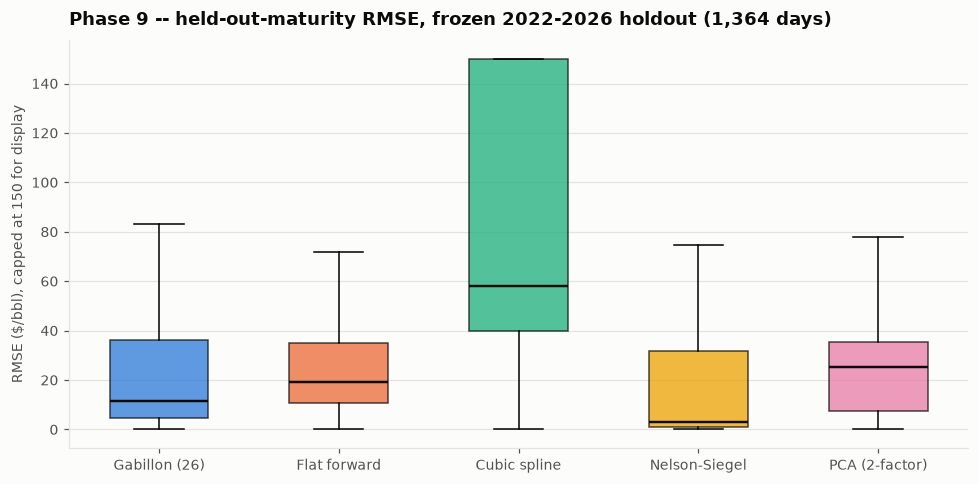

In [21]:
# Chart: holdout RMSE distribution, Gabillon vs. each benchmark -- visualising the one
# and only holdout run already saved in phase_9_23_holdout_results.parquet (no re-fit).
heldout9 = pd.read_parquet("tmp/phase_9_23_holdout_results.parquet")
CAP9 = 150.0  # display cap only; the true (uncapped) values are what Phase 9 scored

fig, ax = vz.new_fig((9, 4.5))
data9 = [vz.clip_for_display(heldout9[c].to_numpy(), CAP9) for c in cols]
bp = ax.boxplot(
    data9,
    tick_labels=[vz.SERIES_LABEL[c] for c in cols],
    patch_artist=True,
    widths=0.55,
    showfliers=False,
    medianprops={"color": vz.TEXT_PRIMARY, "linewidth": 1.6},
)
for patch, c in zip(bp["boxes"], cols):
    patch.set_facecolor(vz.SERIES_COLOR[c])
    patch.set_alpha(0.75)
    patch.set_edgecolor(vz.TEXT_PRIMARY)
vz.style_ax(
    ax,
    title="Phase 9 -- held-out-maturity RMSE, frozen 2022-2026 holdout (1,364 days)",
    ylabel="RMSE ($/bbl), capped at 150 for display",
)
fig.tight_layout()
plt.show()

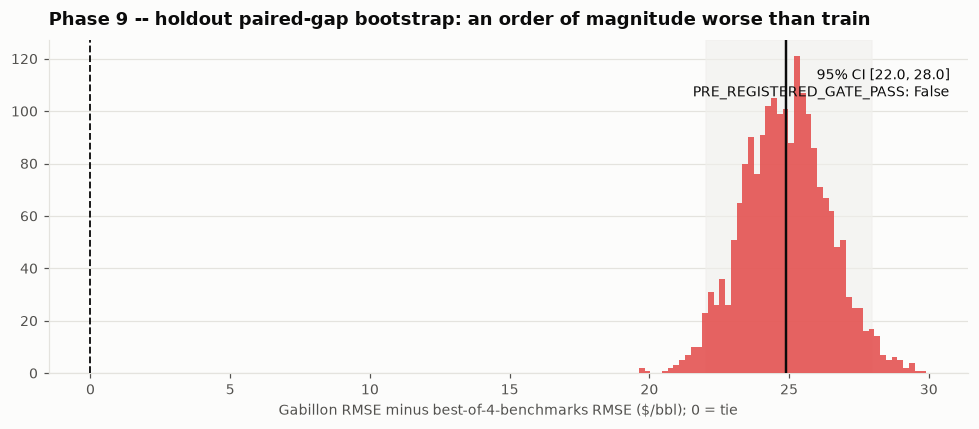

In [22]:
# Chart: holdout paired-gap bootstrap (same procedure as Phase 6's chart, on the holdout)
best_bench9 = heldout9[bench_cols].min(axis=1)
diff9 = (heldout9["gabillon26"] - best_bench9).dropna().to_numpy()
rng9 = np.random.default_rng(23)
boot9 = np.array(
    [np.mean(rng9.choice(diff9, size=len(diff9), replace=True)) for _ in range(2000)]
)
ci9_lo, ci9_hi = np.percentile(boot9, [2.5, 97.5])

fig, ax = vz.new_fig((9, 4))
ax.hist(boot9, bins=50, color=vz.DIVERGE_POS, alpha=0.85, zorder=3)
ax.axvline(0, color=vz.TEXT_PRIMARY, lw=1.2, ls="--", zorder=4)
ax.axvspan(ci9_lo, ci9_hi, color=vz.NEUTRAL, alpha=0.6, zorder=1)
ax.axvline(np.mean(diff9), color=vz.TEXT_PRIMARY, lw=1.6, zorder=5)
vz.style_ax(
    ax,
    title="Phase 9 -- holdout paired-gap bootstrap: an order of magnitude worse than train",
    xlabel="Gabillon RMSE minus best-of-4-benchmarks RMSE ($/bbl); 0 = tie",
)
ax.annotate(
    f"95% CI [{ci9_lo:.1f}, {ci9_hi:.1f}]\nPRE_REGISTERED_GATE_PASS: {phase9['PRE_REGISTERED_GATE_PASS']}",
    xy=(0.98, 0.92),
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=9,
    color=vz.TEXT_PRIMARY,
)
fig.tight_layout()
plt.show()

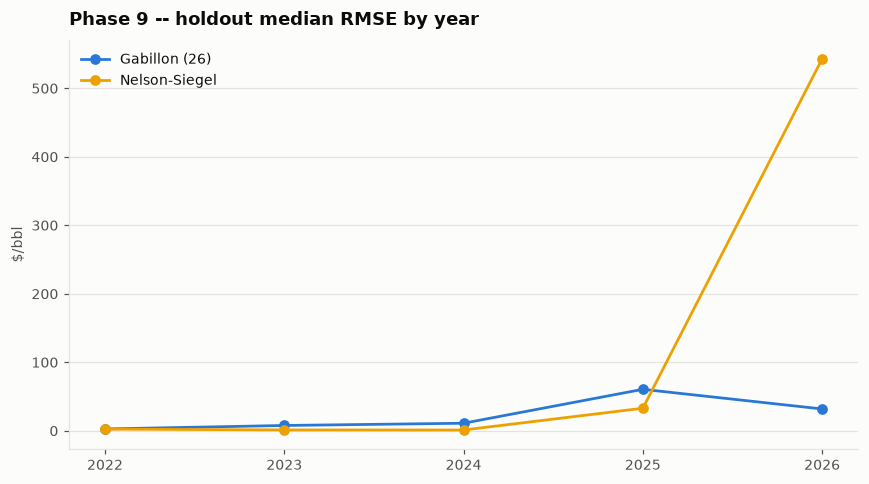

In [23]:
# Chart: holdout RMSE by year -- the 2025 degradation
by_year9 = phase9["by_year"]
years9 = sorted(by_year9, key=int)
gab9 = [by_year9[y]["median_gabillon26"] for y in years9]
ns9 = [by_year9[y]["median_ns"] for y in years9]

fig, ax = vz.new_fig((8, 4.5))
x = np.arange(len(years9))
ax.plot(x, gab9, color=vz.BLUE, marker="o", lw=1.8, label="Gabillon (26)", zorder=3)
ax.plot(x, ns9, color=vz.YELLOW, marker="o", lw=1.8, label="Nelson-Siegel", zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(years9)
vz.style_ax(ax, title="Phase 9 -- holdout median RMSE by year", ylabel="$/bbl")
vz.legend(ax, loc="upper left")
fig.tight_layout()
plt.show()

## Bottom line

See `src/results/023_gabillon_two_factor_oil_curve.md` for the full write-up.